# Moosic: Automating Playlist Creation with Clustering

Moosic is a startup where a small team of music experts handcrafts playlists based on mood and style. 
The problem: business is growing faster than the team can keep up. 
We were brought in to find out whether Spotify's audio features alone are enough to automatically group ~5,000 songs into clusters that could work as playlists.

### Dataset

The dataset contains ~5,200 songs pulled from the [Spotify Web API](https://developer.spotify.com/documentation/web-api/reference/get-audio-features). 
For each song we get numerical audio features like danceability, energy, tempo, and so on, all computed by Spotify from the raw audio signal. 
There are no genre labels, no lyrics, and no user listening data in here. Just the numbers.

### How long should a playlist be?

Before touching any algorithm, we wanted to know what a good playlist actually looks like in practice. 
A [Chartmetric analysis](https://hmc.chartmetric.com/the-optimal-playlist-length-for-the-top-playlists-on-each-streaming-platform/) 
of top playlists found that Spotify's biggest editorial playlists (Today's Top Hits, RapCaviar) sit at exactly **50 tracks**, 
with the top 10 averaging **58 tracks**. 
Shorter, focused playlists outperform bloated ones because listeners start skipping when there's too much filler.

We use this as a rough target, but the actual size will depend on what the data and the algorithms give us.

### Approach

We first run **DBSCAN** to check whether the data has obvious outliers worth removing, then use **K-Means** to do the actual grouping into playlist candidates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import set_config
from IPython.display import display

# transformer outputs as DataFrames instead of numpy arrays
set_config(transform_output='pandas')
sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('../data/3_spotify_5000_songs.csv')
df.columns = df.columns.str.strip()
print(f'{df.shape[0]} songs, {df.shape[1]} columns')
df.head()

5235 songs, 19 columns


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


## Exploratory Data Analysis

Before we cluster anything, we need to understand what we're working with. The Spotify API gives us these audio features per song:

| Feature | Range | What it measures |
|---|---|---|
| **danceability** | 0.0 - 1.0 | How suitable a track is for dancing, based on tempo, rhythm stability, beat strength, and overall regularity |
| **energy** | 0.0 - 1.0 | Perceptual measure of intensity and activity. Death metal scores high, a Bach prelude scores low |
| **loudness** | -60 - 0 dB | Overall volume in decibels, averaged across the entire song |
| **speechiness** | 0.0 - 1.0 | Presence of spoken words. Above 0.66 is probably all speech (podcast, audiobook), below 0.33 is mostly music |
| **acousticness** | 0.0 - 1.0 | Confidence that a track is acoustic (no electronic amplification) |
| **instrumentalness** | 0.0 - 1.0 | Predicts whether a track has no vocals. Values above 0.5 are intended to represent instrumental tracks |
| **liveness** | 0.0 - 1.0 | Detects the presence of a live audience. Values above 0.8 suggest the track was performed live |
| **valence** | 0.0 - 1.0 | Musical positiveness. High valence sounds happy/cheerful, low valence sounds sad/angry |
| **tempo** | 0 - 250 BPM | Estimated beats per minute |
| **key** | 0 - 11 | The musical key (0=C, 1=C#, 2=D, ... 11=B). Categorical, not continuous |
| **mode** | 0 or 1 | Major (1) or minor (0). Binary |
| **duration_ms** | milliseconds | Length of the track |
| **time_signature** | 1 - 7 | Estimated time signature (3 = 3/4 waltz, 4 = 4/4 standard) |

Let's see how these are distributed across our ~5,200 songs.

In [3]:
df.describe()

,Unnamed: 0,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,5235.00000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5.235000e+03,5235.000000
mean,2617.00000,0.509503,0.653565,5.254441,-9.338098,0.646227,0.083178,0.290043,0.257337,0.185354,0.443596,118.721407,2.479112e+05,3.902961
std,1511.35866,0.218041,0.288335,3.571559,6.294850,0.478185,0.071193,0.355985,0.370686,0.149410,0.277725,28.568463,1.356330e+05,0.420324
min,0.00000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.276000e+04,0.000000
25%,1308.50000,0.309000,0.479000,2.000000,-11.337000,0.000000,0.039000,0.002450,0.000001,0.092500,0.196000,96.174000,1.899910e+05,4.000000
50%,2617.00000,0.539000,0.738000,5.000000,-7.338000,1.000000,0.055800,0.095400,0.001880,0.125000,0.417000,119.180000,2.246670e+05,4.000000
75%,3925.50000,0.688000,0.893000,8.000000,-5.264000,1.000000,0.098650,0.565500,0.643000,0.237000,0.677000,134.019000,2.717200e+05,4.000000
max,5234.00000,0.967000,1.000000,11.000000,1.342000,1.000000,0.918000,0.996000,0.985000,0.987000,0.985000,213.990000,3.815787e+06,5.000000


### Data Cleaning: Duplicates

Quick sanity check before we go further: are there duplicates? 
If the same song appears twice, it gets double the weight in clustering, which we don't want.

We match on **name + artist** (case-insensitive) rather than name alone, since different songs can share the same title (think "Always On My Mind" by Elvis Presley vs. Pet Shop Boys).

In [4]:
# case-insensitive duplicate detection on name + artist
df['_dedup_key'] = df['name'].str.lower().str.strip() + ' | ' + df['artist'].str.lower().str.strip()

n_dupes = df['_dedup_key'].duplicated().sum()
print(f'Found {n_dupes} duplicate songs ({n_dupes / len(df) * 100:.1f}% of dataset)')

df = df.drop_duplicates(subset='_dedup_key').drop(columns='_dedup_key')
print(f'After removal: {len(df)} unique songs')

Found 123 duplicate songs (2.3% of dataset)
After removal: 5112 unique songs


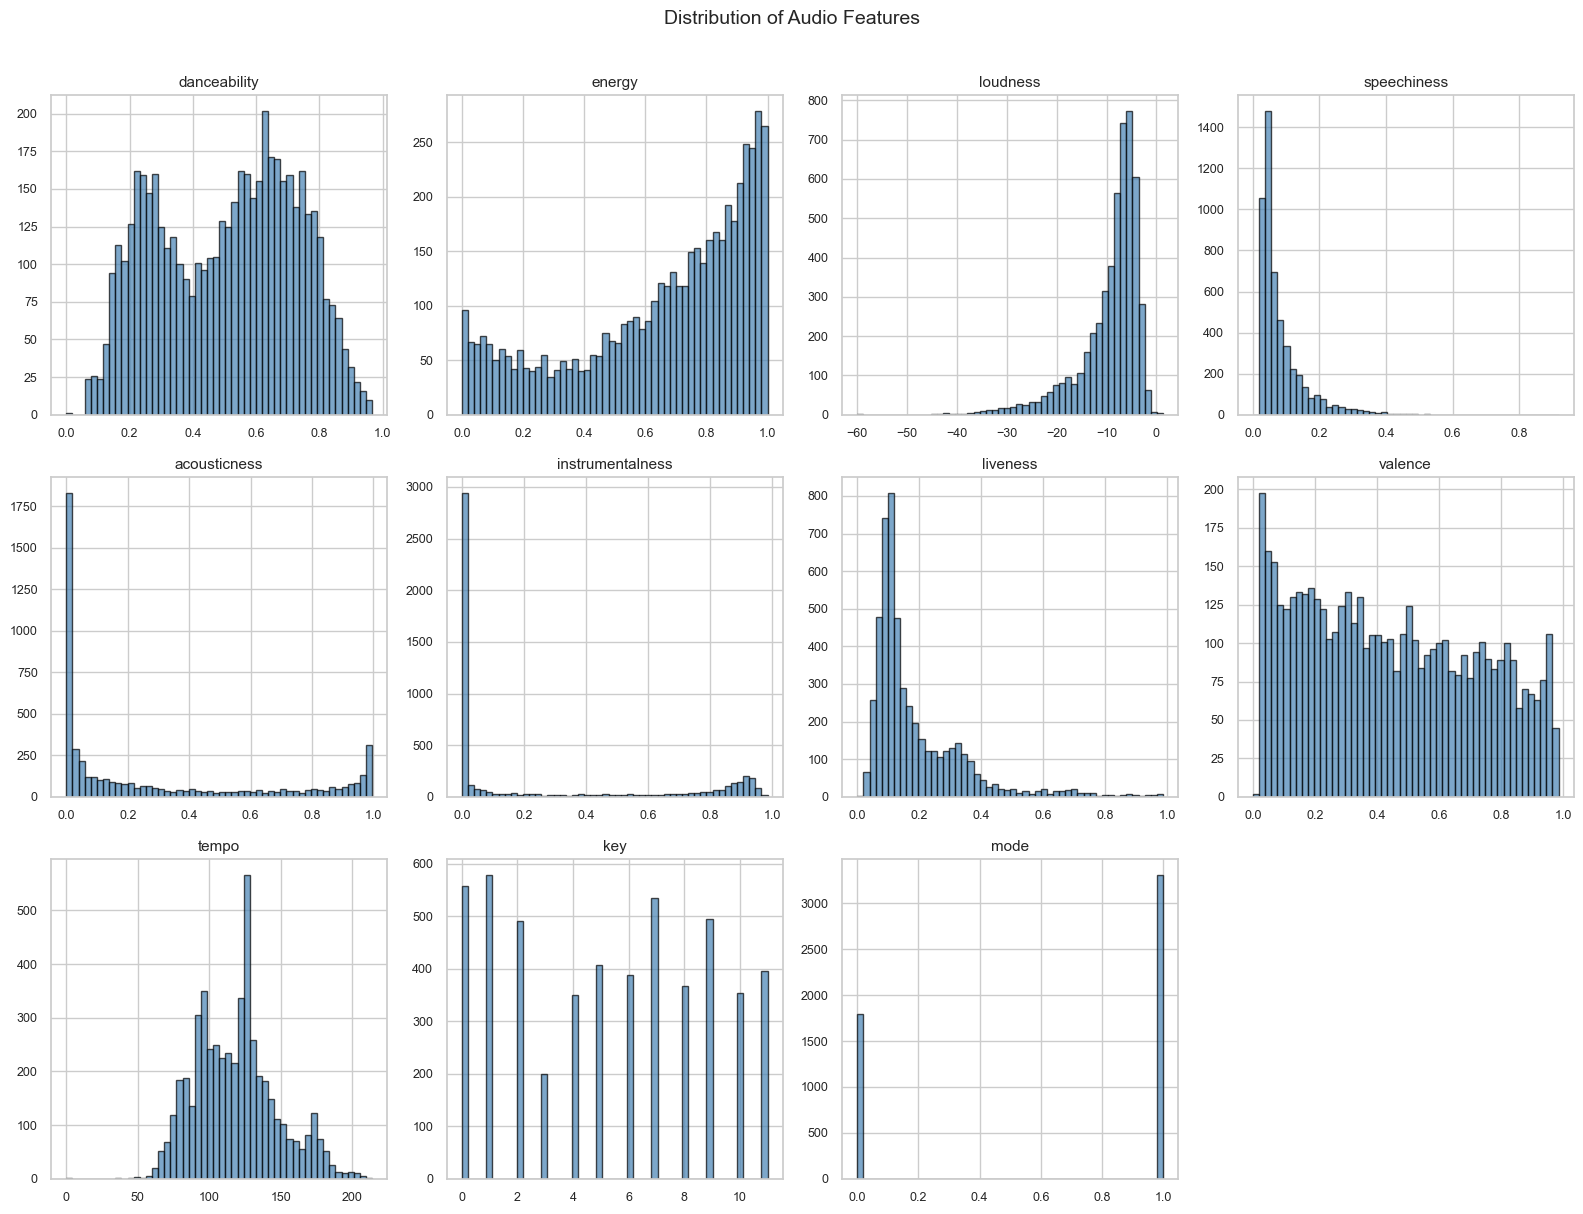

In [5]:
audio_cols = ['danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'key', 'mode']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, col in enumerate(audio_cols):
    ax = axes[i // 4, i % 4]
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.tick_params(labelsize=9)

# hide the empty subplot
axes[2, 3].set_visible(False)

fig.suptitle('Distribution of Audio Features', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

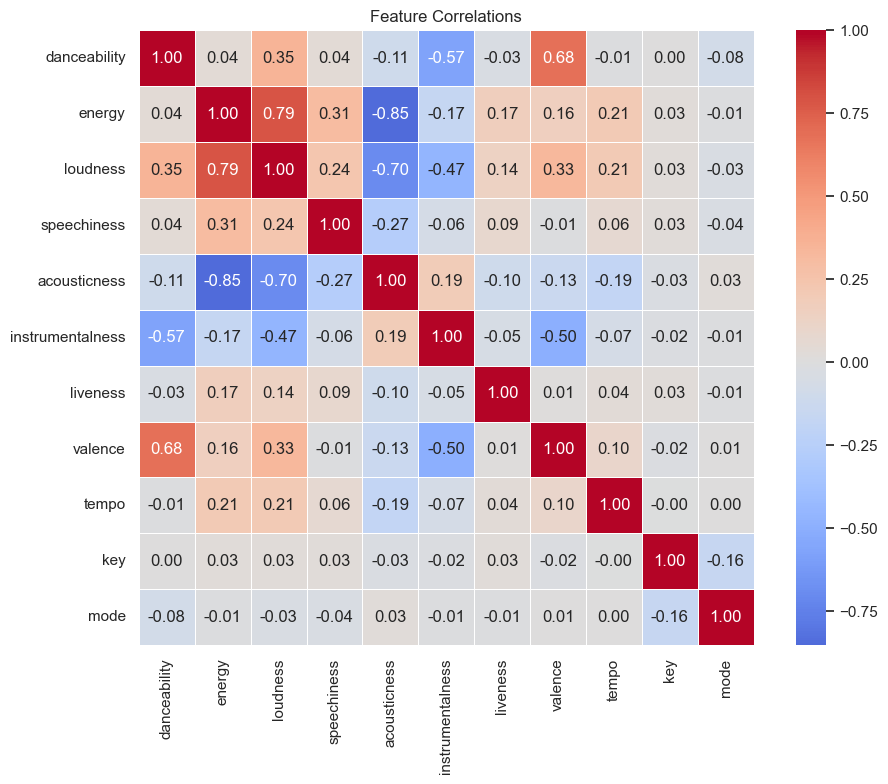

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[audio_cols].corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

### What we see

**Loudness and energy** correlate at ~0.7, which makes sense. Louder songs feel more energetic. 
Since they capture overlapping information, keeping both would just add redundancy. We'll drop loudness and keep energy because it's more perceptually meaningful for playlists.

**Acousticness and energy** are negatively correlated. Acoustic tracks tend to be softer and calmer, so that checks out.

**Instrumentalness** is heavily skewed. The vast majority of songs have vocals (values near 0), with a small group of instrumental pieces way out on the right.

**Speechiness** looks similar. A handful of tracks (probably rap or spoken word) sit at the high end, but most songs cluster near zero.

**Valence** is roughly uniform between 0 and 1. That's actually good news: it means we have a decent spread of happy and sad songs for the algorithm to work with.

**Tempo** ranges from about 50 to 240 BPM while most other features live between 0 and 1. This scale difference is going to matter once we start computing distances, so we'll need to normalize.

**Key** is distributed roughly evenly across all 12 musical keys, with slight peaks at certain ones. But key is categorical and circular: the distance between key 0 (C) and key 11 (B) is just one semitone musically, yet a distance algorithm would treat it as the maximum gap. That makes key unusable for our purposes.

**Mode** is a binary flag (major vs. minor), with about 65% major. A single binary feature in a space full of continuous features just adds noise.

## Feature Selection

Not every column belongs in a clustering model. Distance-based algorithms like K-Means and DBSCAN compute distances between data points, so we need features where "closer = more similar" actually makes sense.

**Dropped (metadata):** name, artist, id, html, Unnamed: 0, type. These are identifiers, not audio properties.

**Dropped (low information):**
- **duration_ms**: Song length says almost nothing about mood or genre. A 3-minute pop song and a 3-minute punk track have nothing in common just because they're the same length.
- **time_signature**: 89% of songs are in 4/4 time. Almost no variance means almost no clustering power.

**Dropped (incompatible with distance metrics):**
- **key** (0 to 11): Represents musical keys (C, C#, D, ..., B). The problem is circularity: key 0 (C) and key 11 (B) are one semitone apart musically, but a distance algorithm treats them as maximally far apart.
- **mode** (0 or 1): Binary flag for major vs. minor. One binary feature among many continuous ones gets drowned out and adds more noise than signal.

That leaves **9 continuous audio features** as candidates. But should we really use all 9? Let's look closer.

In [7]:
candidates = ['danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# 1) Skewness: heavily skewed features pile most values near 0, giving little separation
skew = df[candidates].skew().round(2)

# 2) Correlation: features that correlate strongly with another are redundant
corr = df[candidates].corr()
# for each feature, show its highest absolute correlation with any other feature
high_corr = {}
for col in candidates:
    others = corr[col].drop(col).abs()
    top = others.idxmax()
    high_corr[col] = f'{others.max():.2f} (with {top})'

summary = pd.DataFrame({
    'skewness': skew,
    'highest_correlation': high_corr,
    'std': df[candidates].std().round(3)
})

print('Feature analysis for selection:\n')
display(summary)
print()

# flag problematic features
print('Issues found:')
for feat in candidates:
    issues = []
    if abs(skew[feat]) > 1.5:
        issues.append(f'heavily skewed ({skew[feat]})')
    pair_corr = corr[feat].drop(feat).abs()
    if pair_corr.max() > 0.5:
        top = pair_corr.idxmax()
        issues.append(f'high correlation with {top} ({pair_corr.max():.2f})')
    if issues:
        print(f'  {feat}: {", ".join(issues)}')

Feature analysis for selection:



,skewness,highest_correlation,std
danceability,-0.11,0.68 (with valence),0.218
energy,-0.79,0.85 (with acousticness),0.290
loudness,-1.94,0.79 (with energy),6.306
speechiness,2.59,0.31 (with energy),0.071
acousticness,0.92,0.85 (with energy),0.357
instrumentalness,0.93,0.57 (with danceability),0.372
liveness,2.19,0.17 (with energy),0.150
valence,0.24,0.68 (with danceability),0.278
tempo,0.42,0.21 (with loudness),28.622



Issues found:
  danceability: high correlation with valence (0.68)
  energy: high correlation with acousticness (0.85)
  loudness: heavily skewed (-1.94), high correlation with energy (0.79)
  speechiness: heavily skewed (2.59)
  acousticness: high correlation with energy (0.85)
  instrumentalness: high correlation with danceability (0.57)
  liveness: heavily skewed (2.19)
  valence: high correlation with danceability (0.68)


### Narrowing down to 4 features

The analysis above flags clear problems with several of the remaining candidates:

- **loudness** correlates with energy at 0.79. Keeping both is redundant. We keep energy because it's more perceptually meaningful.
- **acousticness** correlates with energy at 0.85. Same story.
- **speechiness, instrumentalness, liveness** are all heavily skewed. Most songs sit near 0, which means these features barely help separate the bulk of the data.

That leaves us with **4 features** that are neither skewed nor redundant:

| Feature | Why it matters for playlists |
|---|---|
| **danceability** | Captures rhythm and groove, a core mood dimension |
| **energy** | Separates calm tracks from intense ones |
| **valence** | Distinguishes happy from melancholic songs |
| **tempo** | Groups songs by speed, which matters for playlist flow |

Together these cover the main dimensions of how a song *feels*: fast vs. slow, calm vs. intense, happy vs. sad, danceable vs. not.

In [8]:
features = ['danceability', 'energy', 'valence', 'tempo']

# keep metadata so we can inspect actual playlists later
song_info = df[['name', 'artist']].copy()

X = df[features].copy()
print(f'Working with {X.shape[1]} features, {X.shape[0]} songs')
X.head()

Working with 4 features, 5112 songs


,danceability,energy,valence,tempo
0,0.658,0.2590,0.306,110.376
1,0.742,0.3990,0.693,125.039
2,0.851,0.7300,0.905,93.698
3,0.705,0.0502,0.524,106.802
4,0.651,0.1190,0.402,120.941


## Scaling

Our features live on different scales. Danceability, energy, and valence go from 0 to 1, but tempo reaches up to ~240 BPM. Without scaling, tempo would dominate every distance calculation simply because its numbers are bigger, not because it matters more.

We use **MinMaxScaler** to compress everything into [0, 1]. This fits naturally since three of our four features are already in that range. Only tempo needs real rescaling.

In [9]:
scaler = MinMaxScaler()
X_mm = scaler.fit_transform(X)


## Testing DBSCAN for Outlier Detection

Before jumping to K-Means, we wanted to check whether DBSCAN could help clean the dataset first. 
DBSCAN is a density-based algorithm that labels songs in sparse regions as **noise**, meaning potential outliers that don't belong to any group. The idea was: remove those, then cluster the rest.

Two parameters control the behavior:
- **eps**: the radius of a song's neighborhood
- **min_samples**: how many neighbors a song needs within that radius to count as a "core" point

To evaluate the results, we use the **silhouette score**. It measures clustering quality on a scale from -1 to +1. 
A score near +1 means songs fit well into their cluster and are far from the next nearest one. 
Near 0 means a song sits right on the boundary between two clusters. 
Below 0 means the song is probably in the wrong cluster entirely.

Let's scan a broad range of eps values to see if DBSCAN picks up any real structure in our data.

In [10]:
# scan eps values from very tight to very loose
eps_values = [0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30, 0.40]
dbscan_scan = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_mm)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    sil = silhouette_score(X_mm, labels) if n_clust >= 2 else None
    dbscan_scan.append({
        'eps': eps,
        'clusters': n_clust,
        'noise': n_noise,
        'noise_pct': round(n_noise / len(labels) * 100, 1),
        'silhouette': round(sil, 4) if sil else None
    })

dbscan_df = pd.DataFrame(dbscan_scan)
dbscan_df

,eps,clusters,noise,noise_pct,silhouette
0,0.050,57,3624,70.9,-0.4374
1,0.075,52,1338,26.2,-0.4559
2,0.100,5,321,6.3,-0.2946
3,0.125,2,89,1.7,-0.0006
4,0.150,1,30,0.6,NaN
5,0.200,1,3,0.1,NaN
6,0.250,1,2,0.0,NaN
7,0.300,1,1,0.0,NaN
8,0.400,1,0,0.0,NaN


### Why DBSCAN doesn't help here

The results speak for themselves: for any eps >= 0.15, DBSCAN finds exactly **one cluster**. 
With smaller eps values it does detect multiple clusters, but with **negative silhouette scores** (worse than random assignment) and noise percentages between 27% and 71%. Those aren't real clusters. DBSCAN is just carving out arbitrary little pockets from the data.

The underlying reason is straightforward. Our 4 features are distributed fairly uniformly across the [0, 1] range (we saw this in the histograms earlier). There are no clear density gaps. The songs fill the 4-dimensional feature space quite evenly, and DBSCAN needs sparse gaps between dense regions to find anything meaningful. This dataset simply doesn't have them.

This isn't something we can fix by tuning parameters. No combination of eps and min_samples will create structure that isn't there. It's a property of the data itself: with well-spread features like danceability, energy, valence, and tempo, the songs form one continuous cloud rather than separated pockets.

**Bottom line:** We skip outlier removal and go straight to K-Means on the full dataset. The feature selection already cleaned up the most problematic dimensions, so the remaining 4 features give K-Means a reasonable space to work with.

## K-Means Clustering

K-Means assigns each song to the nearest of k centroids, recalculates the centroids, and repeats until convergence. It's simple and fast. The tricky part is choosing k, i.e. how many playlists we want.

We look at two metrics to decide:
- **Elbow method**: plot inertia (within-cluster sum of squared distances) against k. Where the curve bends, adding more clusters stops giving us much improvement.
- **Silhouette score**: measures how well each song fits its own cluster compared to neighboring clusters. Ranges from -1 to 1, higher is better.

In [11]:
# playlist size constraints based on Spotify editorial playlists (~50 tracks)
# aiming for 30-150 songs per playlist as initial target
MIN_PLAYLIST = 30
MAX_PLAYLIST = 150

n_songs = len(X_mm)
max_k = n_songs // MIN_PLAYLIST
k_min = max(2, n_songs // MAX_PLAYLIST)
k_max = n_songs // MIN_PLAYLIST

km_results = {}
inertias, silhouettes, cluster_sizes = [], [], []
for k in range(2, max_k + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_mm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_mm, km.labels_))
    sizes = np.bincount(km.labels_)
    cluster_sizes.append((int(sizes.min()), int(sizes.max())))
km_results['MinMaxScaler'] = {
    'inertia': inertias,
    'silhouette': silhouettes,
    'cluster_sizes': cluster_sizes
}

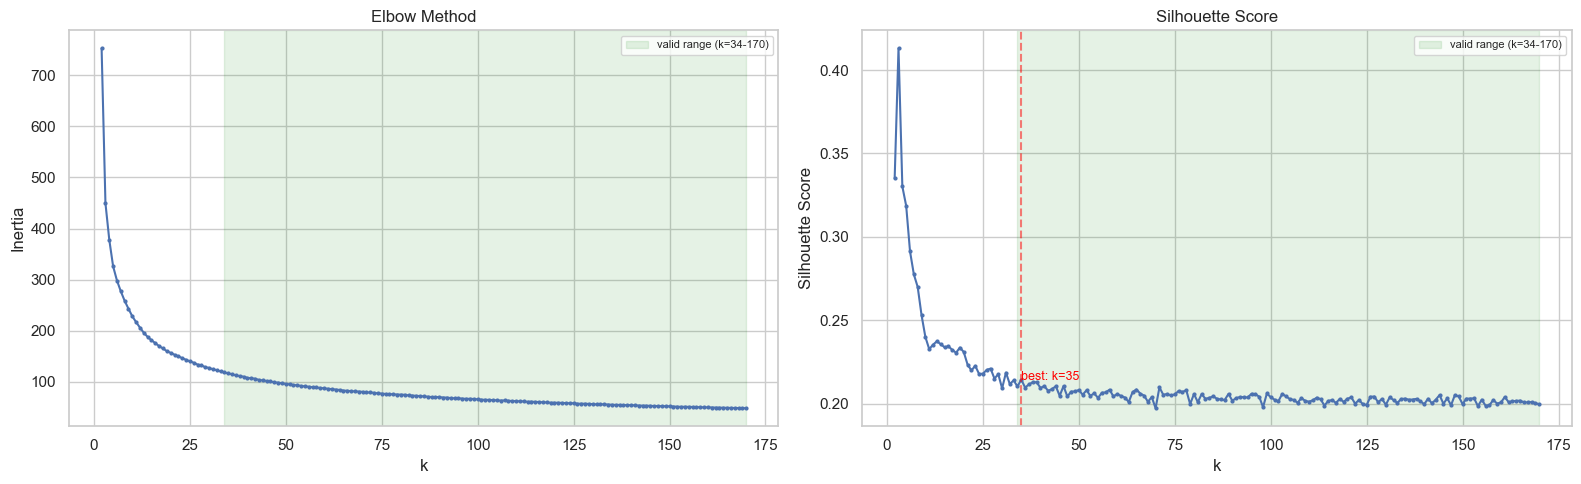

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scores = km_results['MinMaxScaler']['silhouette']
ks = list(range(2, max_k + 1))

# elbow plot
axes[0].plot(ks, km_results['MinMaxScaler']['inertia'], marker='o', markersize=2)
axes[0].axvspan(k_min, k_max, alpha=0.1, color='green',
               label=f'valid range (k={k_min}-{k_max})')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].legend(fontsize=8)

# silhouette plot
axes[1].plot(ks, scores, marker='o', markersize=2)
axes[1].axvspan(k_min, k_max, alpha=0.1, color='green',
               label=f'valid range (k={k_min}-{k_max})')

# best silhouette within valid range
valid_scores = [(k, s) for k, s in zip(ks, scores) if k_min <= k <= k_max]
if valid_scores:
    best_k, best_s = max(valid_scores, key=lambda x: x[1])
    axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.5)
    axes[1].annotate(f'best: k={best_k}', xy=(best_k, best_s),
                     fontsize=9, color='red')

axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


In [13]:
top_rows = []
scores = km_results['MinMaxScaler']['silhouette']
sizes = km_results['MinMaxScaler']['cluster_sizes']
for k, s, (lo, hi) in zip(range(2, max_k + 1), scores, sizes):
    if k_min <= k <= k_max:
        top_rows.append({'k': k, 'silhouette': round(s, 4),
                         'smallest': lo, 'largest': hi,
                         'size_ok': lo >= MIN_PLAYLIST and hi <= MAX_PLAYLIST})

n_ok = sum(1 for r in top_rows if r['size_ok'])
print(f'{n_ok} of {len(top_rows)} k values produce clusters all within {MIN_PLAYLIST}-{MAX_PLAYLIST} songs')

top_rows.sort(key=lambda x: (x['size_ok'], x['silhouette']), reverse=True)
pd.DataFrame(top_rows[:10])


0 of 137 k values produce clusters all within 30-150 songs


,k,silhouette,smallest,largest,size_ok
0,35,0.2144,68,277,False
1,38,0.2129,55,259,False
2,39,0.2129,59,279,False
3,37,0.2116,60,275,False
4,41,0.2106,56,261,False
5,46,0.2106,41,235,False
6,44,0.2105,53,192,False
7,34,0.2104,68,276,False
8,71,0.2098,28,173,False
9,36,0.2097,60,280,False


### The initial constraints don't work

The table tells the story: not a single k value produces clusters that all fall within our 30 to 150 target. 
This isn't a tuning issue. It's how K-Means works. The algorithm has no control over how many songs end up in each cluster. That depends entirely on the data distribution: dense regions in feature space (lots of similar mainstream songs) produce large clusters, sparse regions produce tiny ones.

So we need to relax the constraints to match what the algorithm can actually deliver. The gap between the relaxed range and our editorial target of ~50 songs per playlist would be handled in a post-processing step: splitting oversized playlists and merging small ones.

In [14]:
# relax constraints to what the data actually supports
MIN_PLAYLIST = 15
MAX_PLAYLIST = 250

k_min = max(2, n_songs // MAX_PLAYLIST)
k_max = n_songs // MIN_PLAYLIST

# rebuild the table with relaxed constraints
top_rows = []
for k, s, (lo, hi) in zip(range(2, max_k + 1), scores, sizes):
    if k_min <= k <= k_max:
        top_rows.append({'k': k, 'silhouette': round(s, 4),
                         'smallest': lo, 'largest': hi,
                         'size_ok': lo >= MIN_PLAYLIST and hi <= MAX_PLAYLIST})

n_ok = sum(1 for r in top_rows if r['size_ok'])
print(f'{n_ok} of {len(top_rows)} k values produce clusters all within {MIN_PLAYLIST}-{MAX_PLAYLIST} songs')

top_rows.sort(key=lambda x: (x['size_ok'], x['silhouette']), reverse=True)
pd.DataFrame(top_rows[:10])


71 of 151 k values produce clusters all within 15-250 songs


,k,silhouette,smallest,largest,size_ok
0,46,0.2106,41,235,True
1,44,0.2105,53,192,True
2,71,0.2098,28,173,True
3,40,0.2095,51,238,True
4,43,0.2088,58,242,True
5,65,0.2085,26,182,True
6,58,0.2084,29,178,True
7,50,0.2082,39,193,True
8,52,0.2081,35,186,True
9,78,0.2081,26,155,True


### Choosing k

The elbow plot doesn't show a sharp bend, which is pretty typical for real-world data. The silhouette score gives us a clearer signal.

With the relaxed constraints (15 to 250 songs per playlist), we can now find k values where every cluster fits. We pick the one with the highest silhouette score among those. In production, oversized playlists would still be split and small ones merged to get closer to the ~50 song editorial target.

In [15]:
# pick best k where all clusters fit the constraints
ok_rows = [r for r in top_rows if r['size_ok']]
best = ok_rows[0] if ok_rows else top_rows[0]

K = best['k']
print(f'Chosen k={K} (silhouette: {best["silhouette"]}, range: {best["smallest"]}-{best["largest"]} songs)')
print()

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_mm)

print(f'K-Means (k={K})')
print(f'Silhouette Score: {silhouette_score(X_mm, kmeans_labels):.4f}')
print()
cluster_sizes_km = pd.Series(kmeans_labels, name='count').value_counts().sort_index()
print('Songs per cluster:')
print(cluster_sizes_km.to_string())
print('avg Songs per cluster:')
print(cluster_sizes_km.mean())

Chosen k=46 (silhouette: 0.2106, range: 41-235 songs)

K-Means (k=46)


Silhouette Score: 0.2106

Songs per cluster:
count
0     141
1     110
2     235
3     165
4      95
5     128
6      89
7      55
8     120
9     111
10     68
11    107
12     97
13     96
14    138
15     81
16    101
17     88
18    192
19    182
20     98
21     59
22    156
23    139
24     92
25     64
26     76
27    103
28    161
29    112
30     90
31    115
32     41
33    197
34    162
35     99
36    195
37     74
38     78
39     47
40     77
41     76
42    118
43     67
44     90
45    127
avg Songs per cluster:
111.1304347826087


### How good are the clusters? Silhouette Analysis

The silhouette plot below shows every song as a horizontal bar, grouped by cluster. Here's how to read it:

- A song **close to +1** sits comfortably in its cluster. Its neighbors are all similar, and the next nearest cluster is far away.
- A song **near 0** is right on the boundary between two clusters. Could go either way.
- A song **below 0** is probably in the wrong cluster. It's actually closer to songs in a different group.

Wide, uniform "blades" mean the cluster is well-defined. Thin or jagged blades point to weaker clusters where songs don't fit as cleanly.

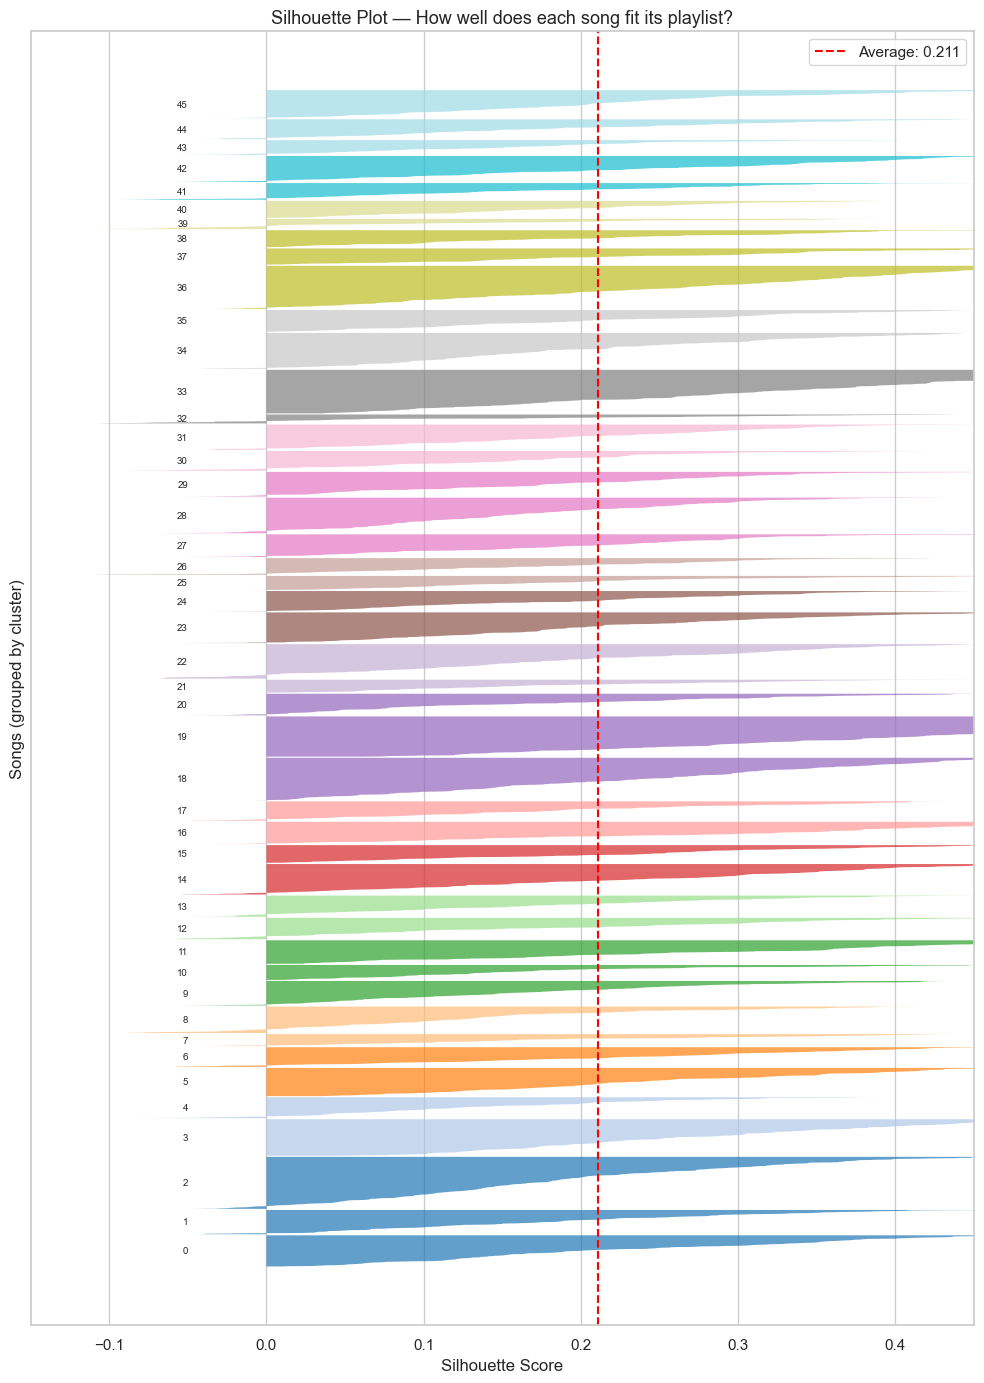


Overall Silhouette Score: 0.2106
Songs with negative silhouette (potential misplacements): 244 (4.8%)


In [16]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(X_mm, kmeans_labels)
sil_avg = silhouette_score(X_mm, kmeans_labels)

fig, ax = plt.subplots(figsize=(10, 14))

y_lower = 0
cluster_order = sorted(set(kmeans_labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_order)))

for i, c in enumerate(cluster_order):
    cluster_sil = np.sort(sil_samples[kmeans_labels == c])
    cluster_size = len(cluster_sil)
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=colors[i % len(colors)], edgecolor='none', alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, str(c),
            fontsize=7, va='center', ha='right')
    y_lower = y_upper + 4  # gap between clusters

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5,
           label=f'Average: {sil_avg:.3f}')
ax.set_xlabel('Silhouette Score', fontsize=12)
ax.set_ylabel('Songs (grouped by cluster)', fontsize=12)
ax.set_title('Silhouette Plot — How well does each song fit its playlist?', fontsize=13)
ax.set_yticks([])
ax.set_xlim([-0.15, 0.45])
ax.legend(fontsize=11, loc='upper right')
fig.tight_layout()
plt.show()

print(f'\nOverall Silhouette Score: {sil_avg:.4f}')
print(f'Songs with negative silhouette (potential misplacements): {(sil_samples < 0).sum()} '
      f'({(sil_samples < 0).sum() / len(sil_samples) * 100:.1f}%)')

In [17]:
# export playlists to CSV
playlist_df = song_info.copy()
playlist_df['cluster'] = kmeans_labels
for feat in features:
    playlist_df[feat] = X[feat].values
playlist_df = playlist_df[['cluster', 'artist', 'name'] + features].sort_values(['cluster', 'artist', 'name'])
playlist_df.to_csv('kmeans_playlists.csv', index=False)
print(f'{len(playlist_df)} songs across {K} playlists saved to kmeans_playlists.csv')

5112 songs across 46 playlists saved to kmeans_playlists.csv


In [18]:
# sample playlists from K-Means clusters
unique_clusters = sorted(set(kmeans_labels))
sample_clusters = [unique_clusters[0], unique_clusters[len(unique_clusters)//2], unique_clusters[-1]]
for c in sample_clusters:
    n = (kmeans_labels == c).sum()
    print(f'--- Cluster {c} ({n} songs) ---')
    cluster_songs = song_info[kmeans_labels == c]
    display(cluster_songs.sample(min(8, len(cluster_songs)), random_state=42)[['name', 'artist']])
    print()

--- Cluster 0 (141 songs) ---


,name,artist
2058,If I Ain't Got You ...,Henry Smith
2550,Conference Of The Birds ...,Dave Holland Quartet
1880,The Unforgettable ...,Dirk Maassen
1981,All of Me ...,Henry Smith
2489,Dedicated To You ...,John Coltrane
5164,"Symphony No. 15 in A Major, Op. 141: I. Allegr...",Dmitri Shostakovich
2126,Late Night Lounge ...,Henry Smith
2599,Polka Dots And Moonbeams - Remastered ...,Bud Powell



--- Cluster 23 (139 songs) ---


,name,artist
5011,Adicto (with Anuel AA & Ozuna) ...,Tainy
2902,Greyhound ...,Swedish House Mafia
1658,Gives You Hell ...,The All-American Rejects
4821,Der Himmel soll warten ...,Sido
2178,Jerry Sprunger (with T-Pain) ...,Tory Lanez
658,No Lie ...,Sean Paul
2286,Let's Go (feat. Big D & Twista) ...,Trick Daddy
2950,Something Just Like This - Don Diablo Remix ...,The Chainsmokers



--- Cluster 45 (127 songs) ---


,name,artist
1286,Heaven Is a Place on Earth ...,Belinda Carlisle
4765,Du hast den schönsten Arsch der Welt - Single ...,Alex C.
2975,On My Mind ...,Disciples
2676,Intoxicated ...,Martin Solveig Vs. GTA
1628,Grace Kelly ...,MIKA
3218,Mi Cama Huele a Ti (feat. Zion & Lennox) ...,"Tito ""El Bambino"""
2970,Freaks - Radio Edit ...,Timmy Trumpet
5126,More Abundantly Medley - Live ...,Ricky Dillard


### What do these playlists look like?

**Cluster 0** (141 songs) is a calm, low-energy collection. The sample includes jazz standards (John Coltrane, Bud Powell, Dave Holland Quartet), a classical symphony (Shostakovich), and mellow piano pieces (Dirk Maassen, Henry Smith). What these songs share is low energy, low danceability, and moderate-to-low tempo. This reads like a "Late Night / Chill" playlist.

**Cluster 23** (139 songs) goes in the opposite direction: upbeat and energetic. We see pop-rock (The All-American Rejects), reggaeton (Tainy, Sean Paul), hip-hop (Trick Daddy, Tory Lanez), and EDM remixes (Swedish House Mafia, The Chainsmokers). The common thread is high energy combined with high danceability. A "Party / Workout" playlist, basically.

**Cluster 45** (127 songs) is also high-energy, but with a distinctly happy, positive feel on top. Belinda Carlisle, MIKA, Timmy Trumpet, and Martin Solveig all share high valence (cheerful mood) combined with fast tempo. This is "Feel-Good / Summer Hits" territory.

The algorithm clearly separates songs along the mood dimensions we selected. Within each cluster, songs share a recognizable vibe even though they span different genres and decades. That said, the genre diversity within clusters (jazz and classical mixed together, reggaeton next to rock) is a visible limitation. Audio features capture *how* a song sounds, not *what style* it belongs to.

## Conclusions and Recommendations

### What we did

We used two algorithms in sequence:

1. **DBSCAN** for outlier detection. Turned out the data is too uniformly distributed in our 4-feature space for DBSCAN to find any meaningful structure. Every eps setting either lumps everything into one cluster or produces arbitrary splits with negative silhouette scores. We decided to skip outlier removal.
2. **K-Means** for the actual playlist generation on the full dataset. This produced musically coherent clusters.

### Feature selection matters

We started with 9 continuous audio features and narrowed them down to **4** (danceability, energy, valence, tempo) based on the statistical analysis. The dropped features were either heavily skewed (speechiness, instrumentalness, liveness), redundant with energy (loudness at 0.79 correlation, acousticness at 0.85), or didn't add meaningful separation.

### Playlist size constraints

Our initial target was 30 to 150 songs per playlist, based on Spotify's editorial standard of ~50 tracks ([Chartmetric](https://hmc.chartmetric.com/the-optimal-playlist-length-for-the-top-playlists-on-each-streaming-platform/)). But K-Means can't control cluster sizes. Those are determined by how the data is distributed. After testing a range of k values, **15 to 250 songs** is where the algorithm delivers valid clusters. In production, a post-processing step would split oversized playlists and merge small ones to get closer to ~50.

### Can Spotify's audio features identify "similar songs"?

To some extent. Features like energy, danceability, and valence do a solid job separating calm acoustic tracks from high-energy dance music. But two songs can have nearly identical audio profiles and still feel completely different because of lyrics, vocal style, or cultural context. Audio features capture the *energy* of a song, not its genre or style.

### What data could improve the results?

- **Genre labels** (even broad ones like "rock", "electronic", "classical") would immediately improve cluster coherence
- **User listening data**, specifically what songs people play back-to-back, would capture the subjective "vibe" that audio features miss
- **Lyrics analysis through NLP** could add another dimension entirely
- **Artist similarity networks** from the Spotify API could help keep related artists together

### Is unsupervised ML the right approach?

For a first prototype without pre-labeled playlists, yes. The moderate silhouette scores tell us the data doesn't have super obvious natural groupings, but the clusters are still musically meaningful when you actually look at the songs inside them.

As Moosic collects user feedback on generated playlists, they could move toward semi-supervised learning, where human input gradually refines what the algorithm produces.

### Recommended next steps

1. Deploy K-Means clustering as the first prototype
2. Add post-processing to split/merge playlists toward the ~50 song editorial target
3. Have the music team review generated playlists and flag problems
4. Pull genre data from the Spotify API to improve cluster coherence
5. Once user listening data is available, use it to validate and refine clusters